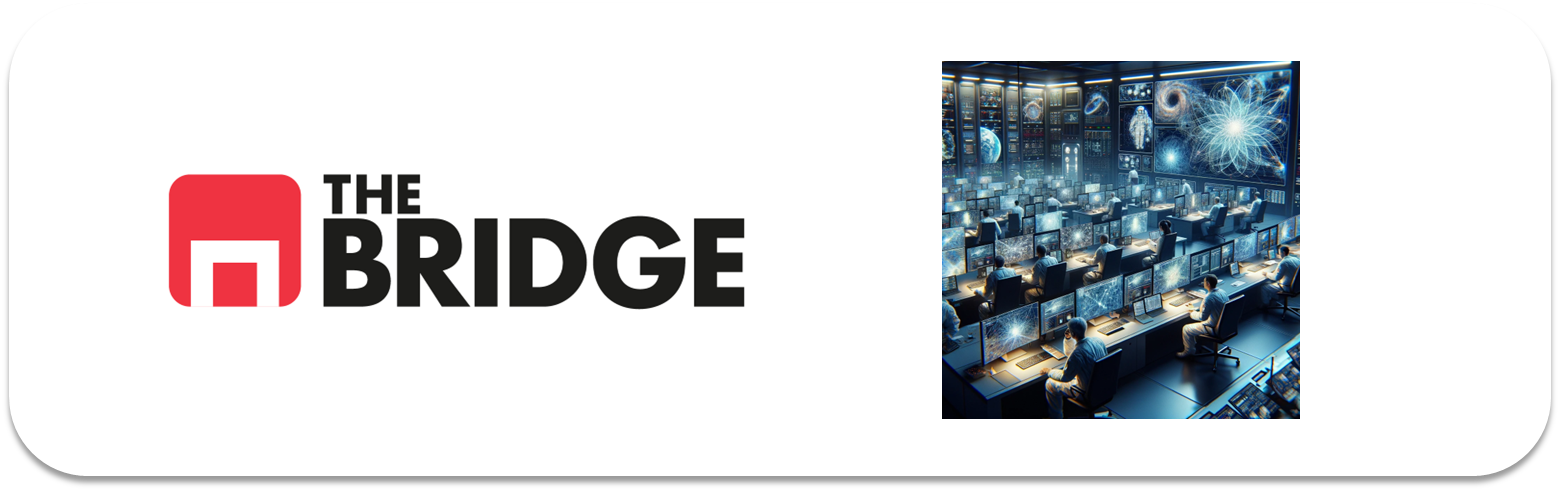

## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import load_img, img_to_array

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.


### Extra (para hacer en clase)

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras. 



In [13]:
data_path = "data"

print(os.listdir(data_path))

['github_test', 'github_train_0', 'github_train_1', 'github_train_3', 'github_train_2']


In [14]:
folders = [
    "github_train_0",
    "github_train_1",
    "github_train_2",
    "github_train_3",
    "github_test"
]

for folder in folders:
    files = os.listdir(os.path.join(data_path, folder))
    print(folder, len(files), files[:3])

github_train_0 1000 ['cat.3406.jpg', 'cat.3374.jpg', 'cat.1205.jpg']
github_train_1 1000 ['cat.1211.jpg', 'cat.952.jpg', 'cat.946.jpg']
github_train_2 1000 ['dog.11102.jpg', 'dog.11664.jpg', 'dog.11670.jpg']
github_train_3 1000 ['dog.11894.jpg', 'dog.11857.jpg', 'dog.10591.jpg']
github_test 1000 ['dog.9469.jpg', 'dog.8763.jpg', 'dog.9455.jpg']


In [15]:
def load_dataset(folder_names):
    images = []
    labels = []
    file_names = []

    for folder_name in folder_names:
        folder_path = os.path.join(data_path, folder_name)

        for file_name in sorted(os.listdir(folder_path)):
            if file_name.startswith("cat"):
                label = 0
            elif file_name.startswith("dog"):
                label = 1
            else:
                continue

            image_path = os.path.join(folder_path, file_name)
            image = load_img(image_path, target_size=(32, 32))
            image = img_to_array(image) / 255.0

            images.append(image)
            labels.append(label)
            file_names.append(file_name)

    return np.array(images), np.array(labels), np.array(file_names)


train_folders = [
    "github_train_0",
    "github_train_1",
    "github_train_2",
    "github_train_3"
]

X_train, y_train, _ = load_dataset(train_folders)
X_test, y_test, test_file_names = load_dataset(["github_test"])

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("Train:", np.unique(y_train, return_counts=True))
print("Test:", np.unique(y_test, return_counts=True))

X_train: (4000, 32, 32, 3)
y_train: (4000,)
X_test: (1000, 32, 32, 3)
y_test: (1000,)
Train: (array([0, 1]), array([2000, 2000]))
Test: (array([0, 1]), array([500, 500]))


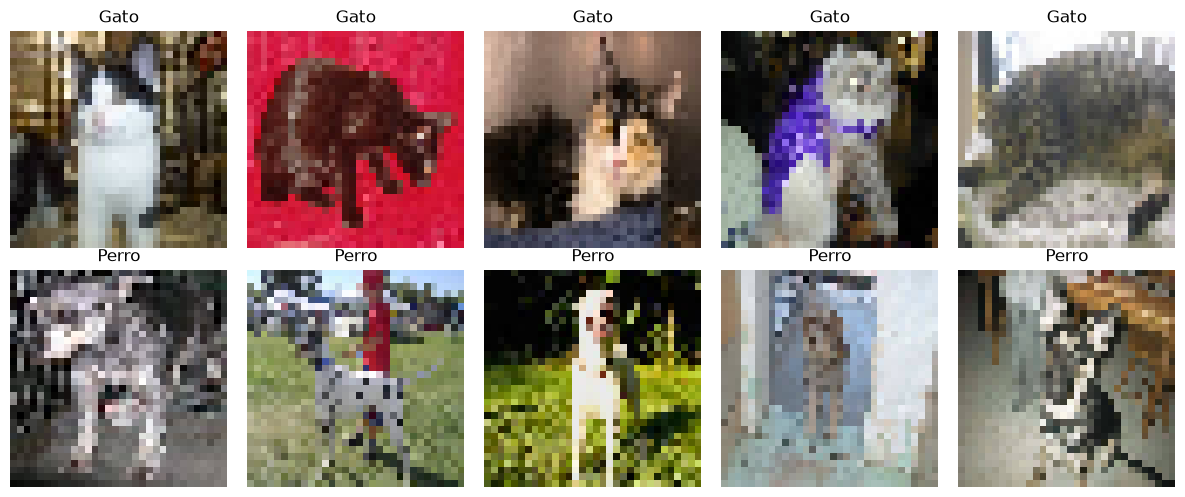

Tamaño de las imágenes: (32, 32, 3)
Valor mínimo de los píxeles: 0.0
Valor máximo de los píxeles: 1.0


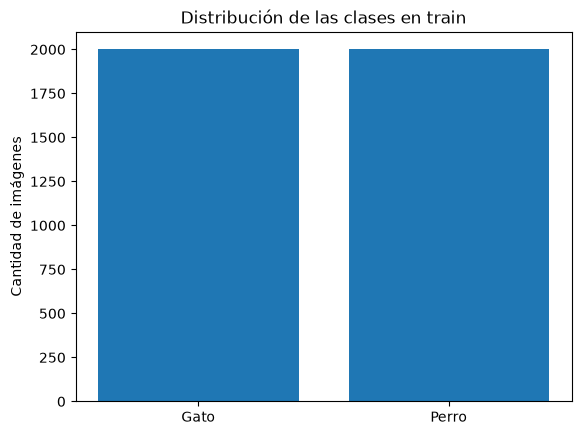

In [16]:
nombres_clases = ["Gato", "Perro"]

indices_gatos = np.where(y_train == 0)[0][:5]
indices_perros = np.where(y_train == 1)[0][:5]
indices_muestra = np.concatenate([indices_gatos, indices_perros])

fig, ejes = plt.subplots(2, 5, figsize=(12, 5))

for eje, indice in zip(ejes.flat, indices_muestra):
    eje.imshow(X_train[indice])
    eje.set_title(nombres_clases[y_train[indice]])
    eje.axis("off")

plt.tight_layout()
plt.show()

print("Tamaño de las imágenes:", X_train[0].shape)
print("Valor mínimo de los píxeles:", X_train.min())
print("Valor máximo de los píxeles:", X_train.max())

cantidad_clases = np.bincount(y_train)

plt.bar(nombres_clases, cantidad_clases)
plt.title("Distribución de las clases en train")
plt.ylabel("Cantidad de imágenes")
plt.show()

In [17]:
modelo = Sequential([
    Input(shape=(32, 32, 3)),

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid")
])

modelo.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

modelo.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,977 (652.25 KB)

 Trainable params: 166,977 (652.25 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
X_entrenamiento, X_validacion, y_entrenamiento, y_validacion = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

parada_temprana = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

historial = modelo.fit(
    X_entrenamiento,
    y_entrenamiento,
    validation_data=(X_validacion, y_validacion),
    epochs=30,
    batch_size=32,
    callbacks=[parada_temprana]
)

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5728 - loss: 0.6811 - val_accuracy: 0.5675 - val_loss: 0.6696
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6494 - loss: 0.6273 - val_accuracy: 0.6463 - val_loss: 0.6244
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6872 - loss: 0.5857 - val_accuracy: 0.6762 - val_loss: 0.5897
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7237 - loss: 0.5362 - val_accuracy: 0.6988 - val_loss: 0.5880
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7459 - loss: 0.5175 - val_accuracy: 0.6913 - val_loss: 0.5985
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7750 - loss: 0.4771 - val_accuracy: 0.7075 - val_loss: 0.5510
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7916 - loss: 0.4362 - val_accuracy: 0.7225 - val_loss: 0.5918
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8056 - loss: 0.4102 - val_accuracy: 0.

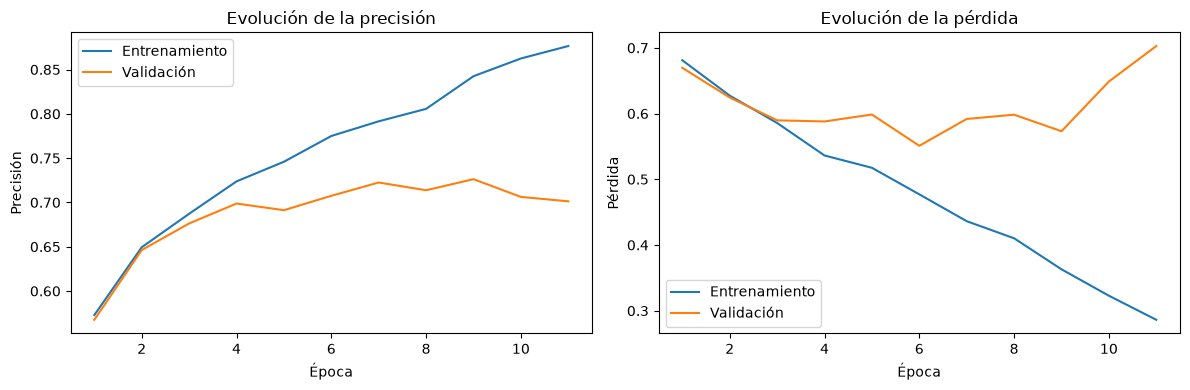

In [19]:
epocas = range(1, len(historial.history["loss"]) + 1)

fig, ejes = plt.subplots(1, 2, figsize=(12, 4))

ejes[0].plot(epocas, historial.history["accuracy"], label="Entrenamiento")
ejes[0].plot(epocas, historial.history["val_accuracy"], label="Validación")
ejes[0].set_title("Evolución de la precisión")
ejes[0].set_xlabel("Época")
ejes[0].set_ylabel("Precisión")
ejes[0].legend()

ejes[1].plot(epocas, historial.history["loss"], label="Entrenamiento")
ejes[1].plot(epocas, historial.history["val_loss"], label="Validación")
ejes[1].set_title("Evolución de la pérdida")
ejes[1].set_xlabel("Época")
ejes[1].set_ylabel("Pérdida")
ejes[1].legend()

plt.tight_layout()
plt.show()

Pérdida en test: 0.5272757411003113
Precisión en test: 0.7680000066757202
              precision    recall  f1-score   support

        Gato       0.75      0.80      0.77       500
       Perro       0.79      0.74      0.76       500

    accuracy                           0.77      1000
   macro avg       0.77      0.77      0.77      1000
weighted avg       0.77      0.77      0.77      1000



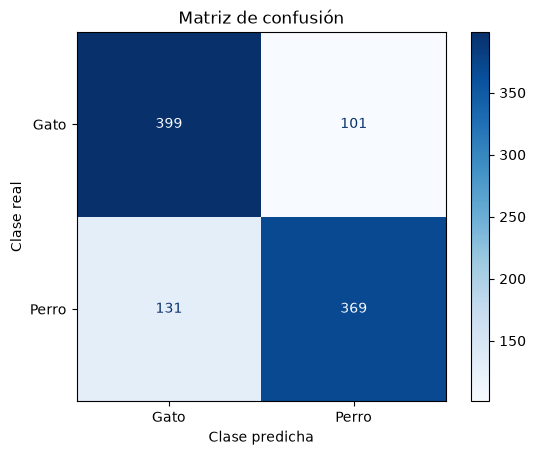

In [24]:
perdida_test, precision_test = modelo.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Pérdida en test:", perdida_test)
print("Precisión en test:", precision_test)

probabilidades = modelo.predict(X_test, verbose=0).ravel()
predicciones = (probabilidades >= 0.5).astype(int)

print(
    classification_report(
        y_test,
        predicciones,
        target_names=nombres_clases
    )
)

matriz = confusion_matrix(y_test, predicciones)

visualizador = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=nombres_clases
)

visualizador.plot(cmap="Blues")
visualizador.ax_.set_xlabel("Clase predicha")
visualizador.ax_.set_ylabel("Clase real")
plt.title("Matriz de confusión")
plt.show()

In [25]:
indices_gatos_error = np.where(
    (y_test == 0) & (predicciones == 1)
)[0]

indices_perros_error = np.where(
    (y_test == 1) & (predicciones == 0)
)[0]

cantidad_gatos = max(1, round(len(indices_gatos_error) * 0.10))
cantidad_perros = max(1, round(len(indices_perros_error) * 0.10))

orden_gatos = np.argsort(
    probabilidades[indices_gatos_error]
)[::-1]

orden_perros = np.argsort(
    1 - probabilidades[indices_perros_error]
)[::-1]

gatos_seleccionados = indices_gatos_error[
    orden_gatos[:cantidad_gatos]
]

perros_seleccionados = indices_perros_error[
    orden_perros[:cantidad_perros]
]

print("Gatos mal clasificados:", len(indices_gatos_error))
print("Gatos seleccionados:", len(gatos_seleccionados))
print("Perros mal clasificados:", len(indices_perros_error))
print("Perros seleccionados:", len(perros_seleccionados))

Gatos mal clasificados: 101
Gatos seleccionados: 10
Perros mal clasificados: 131
Perros seleccionados: 13


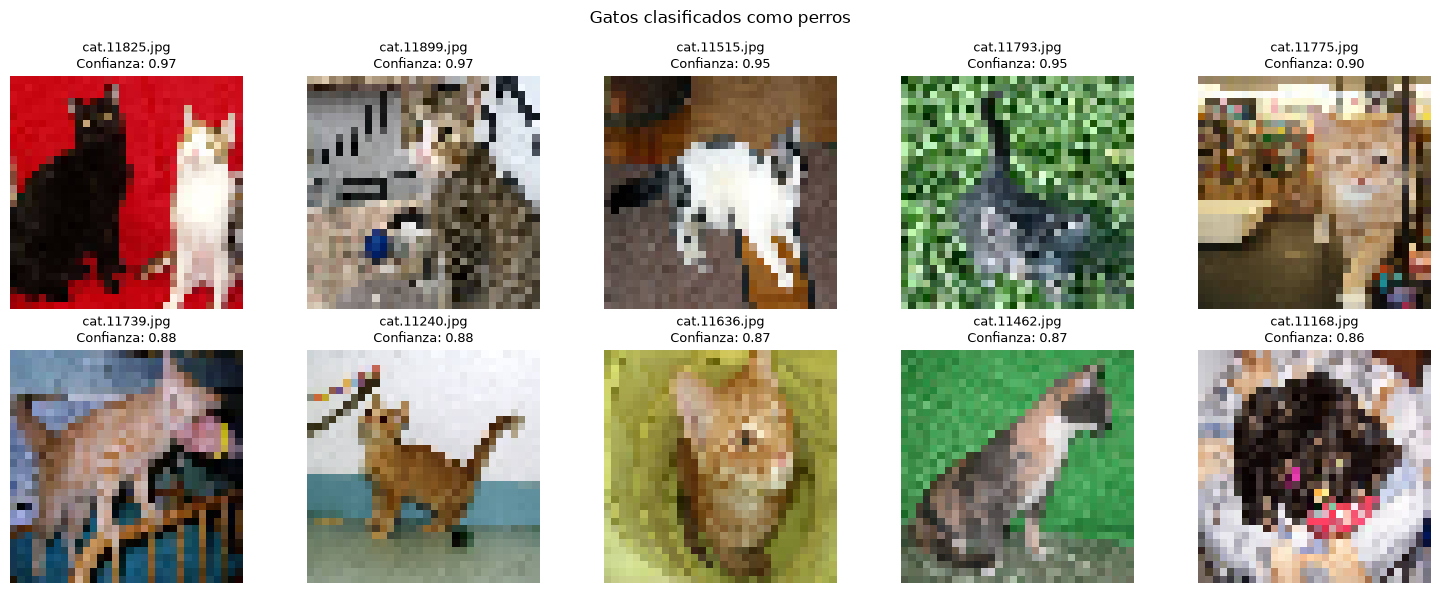

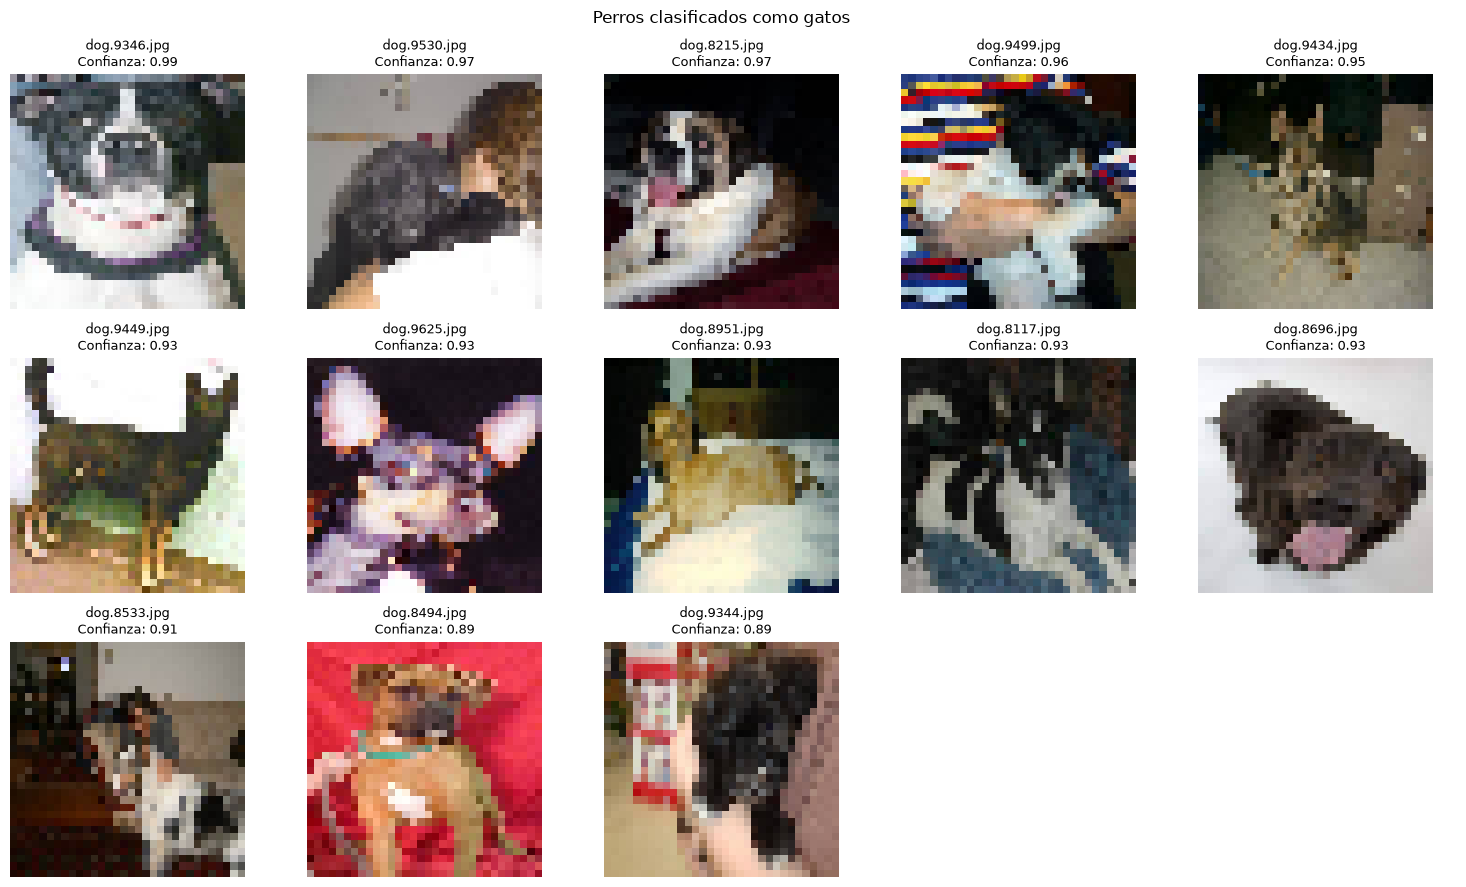

In [26]:
def mostrar_seleccion(indices, titulo):
    columnas = 5
    filas = int(np.ceil(len(indices) / columnas))

    fig, ejes = plt.subplots(
        filas,
        columnas,
        figsize=(15, 3 * filas)
    )

    ejes = np.array(ejes).reshape(-1)

    for eje, indice in zip(ejes, indices):
        if predicciones[indice] == 1:
            confianza_error = probabilidades[indice]
        else:
            confianza_error = 1 - probabilidades[indice]

        eje.imshow(X_test[indice])
        eje.set_title(
            f"{test_file_names[indice]}\nConfianza: {confianza_error:.2f}",
            fontsize=9
        )
        eje.axis("off")

    for eje in ejes[len(indices):]:
        eje.axis("off")

    plt.suptitle(titulo)
    plt.tight_layout()
    plt.show()


mostrar_seleccion(
    gatos_seleccionados,
    "Gatos clasificados como perros"
)

mostrar_seleccion(
    perros_seleccionados,
    "Perros clasificados como gatos"
)

### Conclusión

Primero cargué las 4.000 imágenes de train y las 1.000 de test, cambiando su tamaño a 32x32 y normalizando los píxeles. Los datos estaban equilibrados, con la misma cantidad de gatos y perros.

Después creé una red convolucional con dos bloques de convolución y pooling. Para el entrenamiento usé EarlyStopping, que paró el modelo cuando dejó de mejorar en validación.

El modelo consiguió una precisión del 76,8% en test. Clasificó correctamente 399 gatos y 369 perros, mientras que confundió 101 gatos con perros y 131 perros con gatos.

Por último, seleccioné el 10% de los errores de cada clase en los que el modelo estaba más seguro de su respuesta incorrecta. Así obtuve 10 imágenes de gatos y 13 de perros, que serían las imágenes más difíciles para el modelo y las más interesantes para usar en el CAPTCHA.